In [1]:
## IMPORTS AND SETUP
# Imports
import matplotlib.pyplot as plt
import numpy as np
import os
import tensorflow as tf
import datetime
import zipfile
import pandas as pd
from PIL import Image
import tensorflow_datasets as tfds

# Forcer TensorFlow à utiliser le GPU
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)

    
# Tensorboard setup
%load_ext tensorboard
log_dir = "/workspace/logs/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callback = tf.keras.callbacks.TensorBoard(
    log_dir=log_dir,
    histogram_freq=1,
    write_graph=True,
    update_freq='epoch'
)

2025-04-01 21:38:57.489643: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-04-01 21:38:57.858777: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-04-01 21:38:58.026399: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-04-01 21:38:58.070707: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-04-01 21:38:58.339125: I tensorflow/core/platform/cpu_feature_guar

In [ ]:
def fix_corrupted_images(directory, delete_invalid=True):
    """
    Walks through a directory to detect and fix misformatted image files.
    PNG or GIF files mislabelled as JPG are corrected.
    """
    print(f"Checking directory: {directory}")
    if not os.path.isdir(directory):
        print(f"Directory {directory} doesn't exist")
        return
    else:
        print(f"Directory {directory} exists")

    stats = {"processed": 0, "png_fixed": 0, "gif_fixed": 0, "invalid_removed": 0, "errors": 0}

    for root, dirs, files in os.walk(directory):
        for file in files:
            file_path = os.path.join(root, file)
            stem, extension = os.path.splitext(file)

            if extension.lower() != '.jpg':
                continue

            stats["processed"] += 1

            try:
                with open(file_path, 'rb') as f:
                    header = f.read(4)

                if header[:4] == b'\x89PNG':
                    print(f"PNG detected: {file_path}")
                    new_path = os.path.join(root, f"{stem}.png")
                    os.rename(file_path, new_path)
                    Image.open(new_path).convert('RGB').save(file_path, "JPEG")
                    os.remove(new_path)
                    stats["png_fixed"] += 1

                elif header[:3] == b'GIF':
                    print(f"GIF detected: {file_path}")
                    new_path = os.path.join(root, f"{stem}.gif")
                    os.rename(file_path, new_path)
                    Image.open(new_path).convert('RGB').save(file_path, "JPEG")
                    os.remove(new_path)
                    stats["gif_fixed"] += 1

                elif header[:2] != b'\xff\xd8':
                    print(f"Non-JPEG file detected: {file_path}")
                    if delete_invalid:
                        os.remove(file_path)
                        stats["invalid_removed"] += 1

            except Exception as e:
                print(f"Error processing {file_path}: {e}")
                stats["errors"] += 1
                if delete_invalid:
                    os.remove(file_path)
                    stats["invalid_removed"] += 1

    print(f"\nSummary:")
    print(f"Files processed: {stats['processed']}")
    print(f"PNG files fixed: {stats['png_fixed']}")
    print(f"GIF files fixed: {stats['gif_fixed']}")
    print(f"Invalid files removed: {stats['invalid_removed']}")
    print(f"Errors encountered: {stats['errors']}")

fix_corrupted_images("../Dataset")

In [ ]:
import os
import tensorflow as tf

# Paramètres
path = "../Dataset"
excluded_folder = "Dataset Livrable 2"  # Dossier à exclure
batch_size = 4
img_height = 180
img_width = 180

# Vérifier le chemin et le contenu
print(f"Chemin absolu : {os.path.abspath(path)}")
if not os.path.exists(path):
    raise ValueError("Le chemin spécifié n'existe pas.")
else:
    print(f"Contenu du dossier principal : {os.listdir(path)}")

# Exclure le dossier spécifié
subfolders = [f for f in os.listdir(path) if os.path.isdir(os.path.join(path, f)) and f != excluded_folder]
print(f"Sous-dossiers utilisés pour le dataset : {subfolders}")

# Créer un dataset optimisé à partir du répertoire
try:
    dataset = tf.keras.utils.image_dataset_from_directory(
        path,
        labels="inferred",  # Les labels sont inférés à partir des noms des sous-dossiers
        label_mode="int",  # Labels sous forme d'entiers
        class_names=subfolders,  # Spécifier les classes à inclure
        color_mode="rgb",  # Images en RGB
        batch_size=batch_size,
        image_size=(img_height, img_width),  # Redimensionner les images
        shuffle=True,
        seed=123,
        validation_split=None,  # Pas de validation split ici
        subset=None,
        interpolation="bilinear",
        follow_links=False
    )

    # Afficher les classes détectées
    class_names = dataset.class_names
    print(f"Classes détectées : {class_names}")

    # Précharger les données pour une meilleure performance
    dataset = dataset.prefetch(buffer_size=tf.data.AUTOTUNE)

    # Afficher un exemple
    for images, labels in dataset.take(1):
        print(f"Images batch shape : {images.shape}")
        print(f"Labels batch : {labels.numpy()}")

except Exception as e:
    print(f"Erreur lors de la création du dataset : {e}")

Chemin absolu : /tf/projet/Dataset
Contenu du dossier principal : ['Dataset Livrable 2', 'Painting', 'Photo', 'Schematics', 'Sketch', 'Text']
Sous-dossiers utilisés pour le dataset : ['Painting', 'Photo', 'Schematics', 'Sketch', 'Text']
Found 41398 files belonging to 5 classes.


I0000 00:00:1743543760.275462   62373 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1743543760.275747   62373 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1743543760.275763   62373 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1743543760.557580   62373 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1743543760.557717   62373 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-04-01

Classes détectées : ['Painting', 'Photo', 'Schematics', 'Sketch', 'Text']
Images batch shape : (16, 180, 180, 3)
Labels batch : [4 4 1 1 1 4 1 2 2 0 4 0 4 1 2 1]


2025-04-01 21:42:44.323907: I tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [4]:
# Proportions des splits
train_split = 0.8
val_split = 0.1
test_split = 0.1

# Calculer les tailles
dataset_size = tf.data.experimental.cardinality(dataset).numpy()  # Plus rapide que len(dataset)
train_size = int(train_split * dataset_size)
val_size = int(val_split * dataset_size)
test_size = dataset_size - train_size - val_size

# Mélanger le dataset
dataset = dataset.shuffle(buffer_size=1000, seed=123)

# Diviser le dataset
train_ds = dataset.take(train_size)
remaining_ds = dataset.skip(train_size)
val_ds = remaining_ds.take(val_size)
test_ds = remaining_ds.skip(val_size)



In [5]:
## MODEL CREATION

def create_model(img_height = 180, img_width = 180, num_classes = 5):
    model = tf.keras.Sequential([
        tf.keras.layers.Rescaling(1./255, input_shape=(img_height, img_width, 3)),
        tf.keras.layers.Conv2D(16, 3, padding='same', activation='relu'),
        tf.keras.layers.MaxPooling2D(),
        tf.keras.layers.Conv2D(32, 3, padding='same', activation='relu'),
        tf.keras.layers.MaxPooling2D(),
        tf.keras.layers.Conv2D(64, 3, padding='same', activation='relu'),
        tf.keras.layers.MaxPooling2D(),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dense(num_classes)
        ])
    
    model.compile(optimizer='adam',
                  loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
                  metrics=['accuracy'])
                  
    return model

model = create_model(img_height, img_width, len(class_names))


/usr/local/lib/python3.11/dist-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


2025-04-01 21:44:08.329268: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:10: Filling up shuffle buffer (this may take a while): 361 of 1000
2025-04-01 21:44:13.342413: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:1641] failed to alloc 4294967296 bytes on host: CUDA_ERROR_OUT_OF_MEMORY: out of memory
2025-04-01 21:44:13.342685: W external/local_xla/xla/stream_executor/integrations/device_host_allocator.h:61] could not allocate pinned host memory of size: 4294967296
2025-04-01 21:44:13.342896: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:1641] failed to alloc 3865470464 bytes on host: CUDA_ERROR_OUT_OF_MEMORY: out of memory
2025-04-01 21:44:13.342905: W external/local_xla/xla/stream_executor/integrations/device_host_allocator.h:61] could not allocate pinned host memory of size: 3865470464
2025-04-01 21:44:13.343038: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:1641] failed to alloc 3478923264 bytes on host: CUD

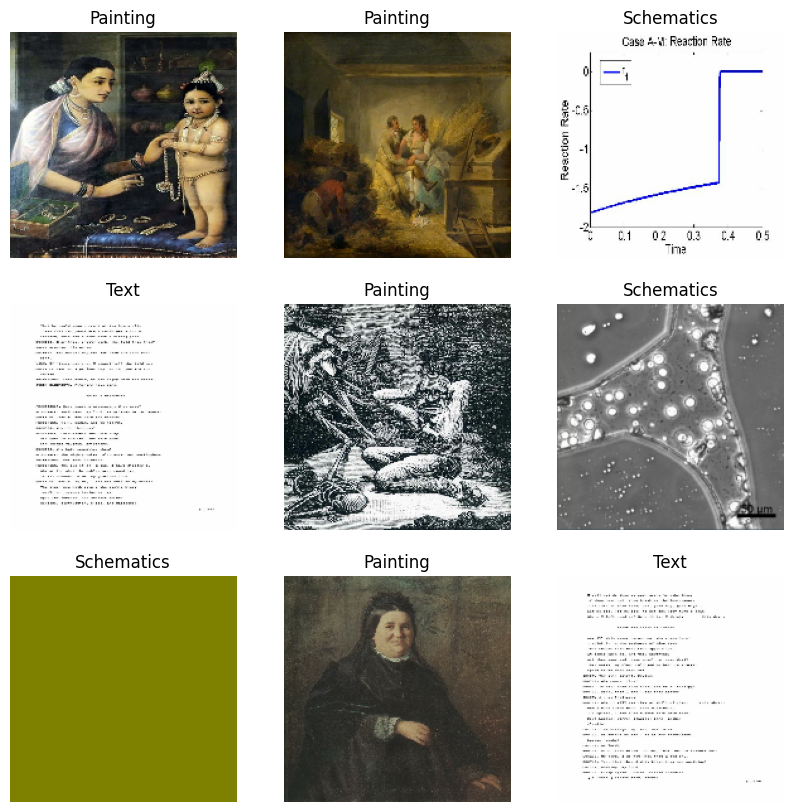

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(min(9, len(images))):  # Limiter à 9 images
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

In [7]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 180, 180, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 90, 90, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 90, 90, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 45, 45, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 45, 45, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 22, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 30976)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,965,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,989,285 (15.22 MB)

 Trainable params: 3,989,285 (15.22 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
# Définir le répertoire des logs pour TensorBoard
import datetime

def create_callbacks(model_name="default_model", tensorboard=True, early_stopping=True, model_checkpoint=True):
    # Répertoire des logs pour TensorBoard
    log_dir = "logs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
    tensorboard_callback = None
    if tensorboard:
        tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1)

    # Définir le callback EarlyStopping
    early_stopping_callback = None
    if early_stopping:
        early_stopping_callback = tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',  # Surveiller la perte de validation
            patience=4,          # Arrêter si aucune amélioration après 4 époques
            restore_best_weights=True  # Restaurer les poids du meilleur modèle
        )

    # Définir le callback ModelCheckpoint
    model_checkpoint_callback = None
    if model_checkpoint:
        checkpoint_dir = "checkpoints"
        os.makedirs(checkpoint_dir, exist_ok=True)  # Créer le dossier si nécessaire
        # Ajouter un horodatage au nom du modèle
        timestamp = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
        model_checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
            filepath=os.path.join(checkpoint_dir, f"{model_name}_{timestamp}.keras"),  # Nom personnalisé avec horodatage
            monitor='val_loss',  # Surveiller la perte de validation
            save_best_only=True,  # Sauvegarder uniquement le meilleur modèle
            verbose=1            # Afficher les logs lors de la sauvegarde
        )
    
    return tensorboard_callback, early_stopping_callback, model_checkpoint_callback


In [9]:
epochs=10
history = model.fit(
  train_ds,
  validation_data=val_ds,
  epochs=epochs,
  callbacks = create_callbacks(model_name="CNN_Model")
)


Epoch 1/10


2025-04-01 21:45:12.085412: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:10: Filling up shuffle buffer (this may take a while): 422 of 1000
2025-04-01 21:45:21.377354: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:480] Shuffle buffer filled.
I0000 00:00:1743543921.429834   66113 service.cc:146] XLA service 0x7fc1e0005fe0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1743543921.434570   66113 service.cc:154]   StreamExecutor device (0): NVIDIA GeForce RTX 4060 Laptop GPU, Compute Capability 8.9
2025-04-01 21:45:21.791047: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-04-01 21:45:22.359606: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:536] Could not create cudnn handle: CUDNN_STATUS_INTERNAL_ERROR
2025-04-01 21:45:22.361157: E external/local_xla/xla/stream_executor/cuda/c

FailedPreconditionError: Graph execution error:

Detected at node StatefulPartitionedCall defined at (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main

  File "<frozen runpy>", line 88, in _run_code

  File "/usr/local/lib/python3.11/dist-packages/ipykernel_launcher.py", line 18, in <module>

  File "/usr/local/lib/python3.11/dist-packages/traitlets/config/application.py", line 1075, in launch_instance

  File "/usr/local/lib/python3.11/dist-packages/ipykernel/kernelapp.py", line 739, in start

  File "/usr/local/lib/python3.11/dist-packages/tornado/platform/asyncio.py", line 205, in start

  File "/usr/lib/python3.11/asyncio/base_events.py", line 604, in run_forever

  File "/usr/lib/python3.11/asyncio/base_events.py", line 1909, in _run_once

  File "/usr/lib/python3.11/asyncio/events.py", line 80, in _run

  File "/usr/local/lib/python3.11/dist-packages/ipykernel/kernelbase.py", line 545, in dispatch_queue

  File "/usr/local/lib/python3.11/dist-pack